# Imports

In [13]:
import yfinance as yf
import pandas as pd
from gurobipy import Model, GRB
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Dataset Preparation

In [3]:
def get_sp500_tickers():
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    tables = pd.read_html(url)
    sp500_tickers = tables[0]['Symbol'].tolist()
    sectors = tables[0]['GICS Sector'].tolist()
    res = dict(zip(sp500_tickers, sectors))
    return sp500_tickers, res

In [5]:
tickers_500, sector_info = get_sp500_tickers()

In [56]:
def fetch_sp500_data(tickers, start_date="2021-01-01", end_date=None):
    final_df = pd.DataFrame()

    for ticker in tickers:
      try:
          stock_data = yf.download(ticker, start=start_date, auto_adjust=False)[["Adj Close"]]
          if(stock_data.empty):
            continue
          pd.DataFrame(stock_data)
          stock_data.rename(columns={"Adj Close": ticker}, inplace=True)
          final_df = pd.concat([final_df, stock_data], axis=1)
          print(f"Downloaded {ticker}")
      except Exception as e:
          print(f"Failed to download {ticker}: {e}")
    return final_df

In [ ]:
df = fetch_sp500_data(tickers_500)

In [58]:
df.head()

Price,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,WMB,WTW,WDAY,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
Ticker,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,WMB,WTW,WDAY,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,121.181175,50.030842,101.045982,88.933952,242.118515,485.339996,92.300003,20.197659,39.074017,115.582764,...,16.255175,192.866287,228.080002,104.627167,57.854454,94.883430,97.808998,378.130005,144.150238,158.001358
2021-01-05,120.976707,50.355610,102.296188,89.853584,243.496872,485.690002,92.769997,20.875547,39.137341,116.527763,...,16.748497,191.256729,225.360001,107.847206,57.290539,94.769226,97.818245,380.570007,146.644348,159.102402
2021-01-06,122.816956,52.090729,102.083176,89.077400,246.159164,466.309998,90.330002,21.709875,40.648197,119.723236,...,17.387379,192.866287,220.000000,108.493164,58.559357,98.766708,98.354347,394.820007,150.823166,161.439743
2021-01-07,119.665276,52.730968,103.074104,90.030754,248.481598,477.739990,95.160004,21.492601,40.422009,122.908974,...,17.419727,194.333817,226.210007,107.416565,57.413895,103.249626,97.605652,409.100006,149.929047,161.294861
2021-01-08,117.479546,52.109276,103.361198,90.503220,249.387924,485.100006,94.580002,22.092272,40.250122,123.785767,...,17.225634,192.809464,227.649994,106.711861,57.942566,102.202660,99.038330,405.470001,149.599640,162.366959


In [59]:
df.shape

(1049, 501)

In [67]:
df.columns = [col[0] if isinstance(col, tuple) else col for col in temp_df.columns]

In [68]:
df.head()

,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,WMB,WTW,WDAY,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,121.181175,50.030842,101.045982,88.933952,242.118515,485.339996,92.300003,20.197659,39.074017,115.582764,...,16.255175,192.866287,228.080002,104.627167,57.854454,94.883430,97.808998,378.130005,144.150238,158.001358
2021-01-05,120.976707,50.355610,102.296188,89.853584,243.496872,485.690002,92.769997,20.875547,39.137341,116.527763,...,16.748497,191.256729,225.360001,107.847206,57.290539,94.769226,97.818245,380.570007,146.644348,159.102402
2021-01-06,122.816956,52.090729,102.083176,89.077400,246.159164,466.309998,90.330002,21.709875,40.648197,119.723236,...,17.387379,192.866287,220.000000,108.493164,58.559357,98.766708,98.354347,394.820007,150.823166,161.439743
2021-01-07,119.665276,52.730968,103.074104,90.030754,248.481598,477.739990,95.160004,21.492601,40.422009,122.908974,...,17.419727,194.333817,226.210007,107.416565,57.413895,103.249626,97.605652,409.100006,149.929047,161.294861
2021-01-08,117.479546,52.109276,103.361198,90.503220,249.387924,485.100006,94.580002,22.092272,40.250122,123.785767,...,17.225634,192.809464,227.649994,106.711861,57.942566,102.202660,99.038330,405.470001,149.599640,162.366959


In [69]:
df.to_csv("sp500_stock_data_new.csv")

# Dataset Load

In [7]:
df = pd.read_csv("sp500_stock_data_new.csv", index_col=0, parse_dates=True)

# Ensure the data format
print(df.head())

                   MMM        AOS         ABT       ABBV         ACN  \
Date                                                                   
2021-01-04  121.181175  50.030842  101.045982  88.933952  242.118515   
2021-01-05  120.976707  50.355610  102.296188  89.853584  243.496872   
2021-01-06  122.816956  52.090729  102.083176  89.077400  246.159164   
2021-01-07  119.665276  52.730968  103.074104  90.030754  248.481598   
2021-01-08  117.479546  52.109276  103.361198  90.503220  249.387924   

                  ADBE        AMD        AES        AFL           A  ...  \
Date                                                                 ...   
2021-01-04  485.339996  92.300003  20.197659  39.074017  115.582764  ...   
2021-01-05  485.690002  92.769997  20.875547  39.137341  116.527763  ...   
2021-01-06  466.309998  90.330002  21.709875  40.648197  119.723236  ...   
2021-01-07  477.739990  95.160004  21.492601  40.422009  122.908974  ...   
2021-01-08  485.100006  94.580002  22.0

In [9]:
# Calculate Daily Return Rate
returns = df.pct_change().dropna()

# Calculate Yearly Return Rate（252 Transaction Days）
expected_returns = returns.mean() * 252

# Calculate Yearly Risk（Cov * 252）
cov_matrix = returns.cov() * 252

print("Expected Returns:\n", expected_returns.head())
print("\nCovariance Matrix:\n", cov_matrix.head())


Expected Returns:
 MMM     0.638879
AOS    -0.179686
ABT     0.488233
ABBV    0.456721
ACN     0.242119
dtype: float64

Covariance Matrix:
            MMM       AOS       ABT      ABBV       ACN      ADBE       AMD  \
MMM   0.125180  0.026971  0.004295  0.013829  0.016267  0.020226  0.030024   
AOS   0.026971  0.068070  0.004646  0.011819  0.012024  0.011381  0.023032   
ABT   0.004295  0.004646  0.040203  0.017371  0.005972  0.005118 -0.014695   
ABBV  0.013829  0.011819  0.017371  0.070290 -0.001520  0.002936 -0.025529   
ACN   0.016267  0.012024  0.005972 -0.001520  0.056716  0.021852  0.017822   

           AES       AFL         A  ...       WMB       WTW      WDAY  \
MMM   0.020335  0.018956  0.021295  ...  0.019453  0.019121  0.015865   
AOS   0.027234  0.007506  0.029665  ...  0.002050  0.007902  0.017796   
ABT   0.007290  0.016913  0.011603  ...  0.006021  0.007182  0.001436   
ABBV  0.004840  0.007142  0.014488  ...  0.000633  0.013779 -0.000736   
ACN  -0.008033  0.014704  

# Data Visualisation

## Stock Prices by Sector

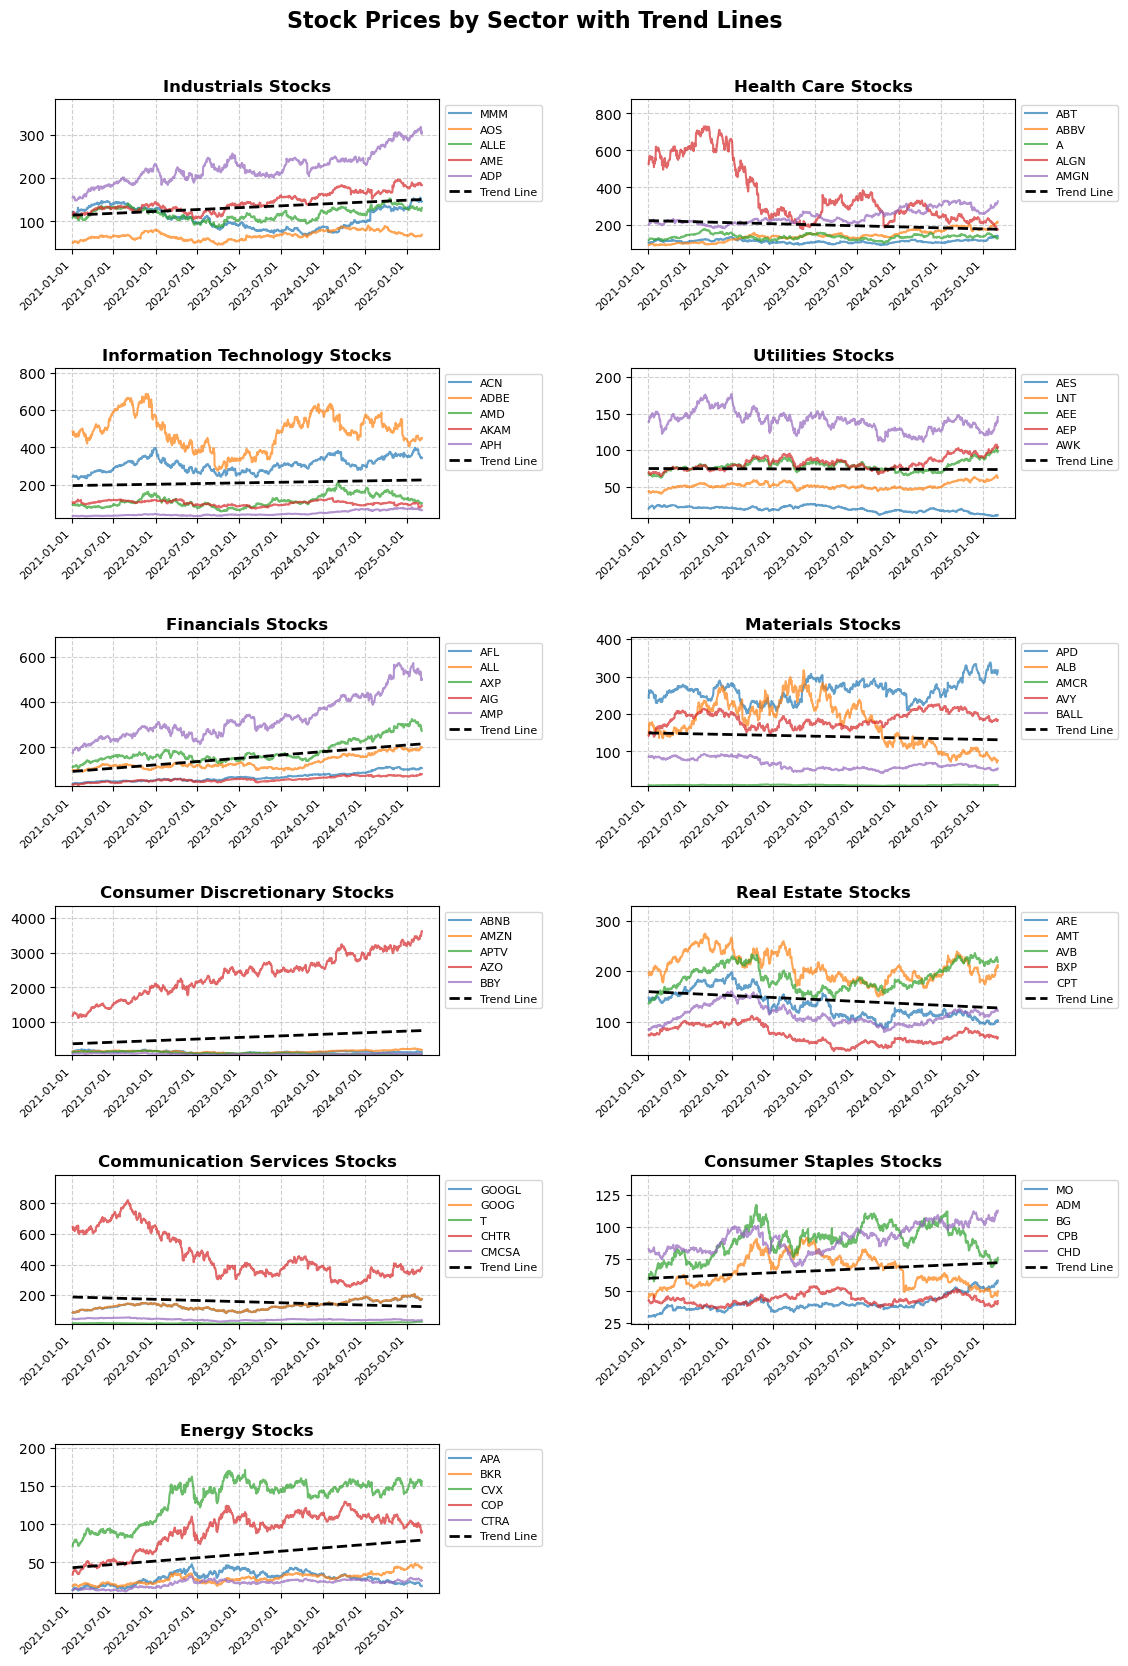

In [64]:
import matplotlib.dates as mdates
import matplotlib.ticker as mticker  

# Defining 5 stocks per sector
sector_groups = {}

for company, sector in sector_info.items():
    if company in df.columns:  # Only include companies that exist in df
        if sector not in sector_groups:
            sector_groups[sector] = []
        if len(sector_groups[sector]) < 5:  # Limit to first 5 companies
            sector_groups[sector].append(company)

# Define subplot layout (adjust rows and cols dynamically)
num_sectors = len(sector_groups)
rows, cols = 6, 2  # Adjust layout based on sector count
fig, axes = plt.subplots(rows, cols, figsize=(12, 18), sharey=False)  # Bigger figure size

axes = axes.flatten()

for i, (sector, stocks) in enumerate(sector_groups.items()):
    ax = axes[i]
    
    sector_data = df[stocks].mean(axis=1)

    for stock in stocks:
        if stock in df.columns:
            ax.plot(df.index, df[stock], label=stock, alpha=0.7, linewidth=1.5)

    # Trend Line
    x = np.arange(len(df.index))  
    y = sector_data.values
    coef = np.polyfit(x, y, 1)  # Linear fit
    trend = np.poly1d(coef)
    ax.plot(df.index, trend(x), linestyle="dashed", color="black", linewidth=2, label="Trend Line")

    # Adjust Y-axis scaling
    min_val, max_val = df[stocks].min().min(), df[stocks].max().max()
    ax.set_ylim(min_val * 0.8, max_val * 1.2)  

    # Improve Date Formatting
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())  
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))  
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

    ax.set_title(f"{sector} Stocks", fontsize=12, fontweight='bold')
    # ax.set_xlabel("Date", fontsize=)
    ax.grid(True, linestyle="--", alpha=0.6)  
    ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1, 1))  

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust Spacing for Clarity
plt.suptitle("Stock Prices by Sector with Trend Lines", fontsize=16, fontweight='bold')
plt.subplots_adjust(left=0.1, right=0.9, top=0.93, bottom=0.1, wspace=0.5, hspace=0.8)  

plt.show()

## Average Stock Returns Distribution

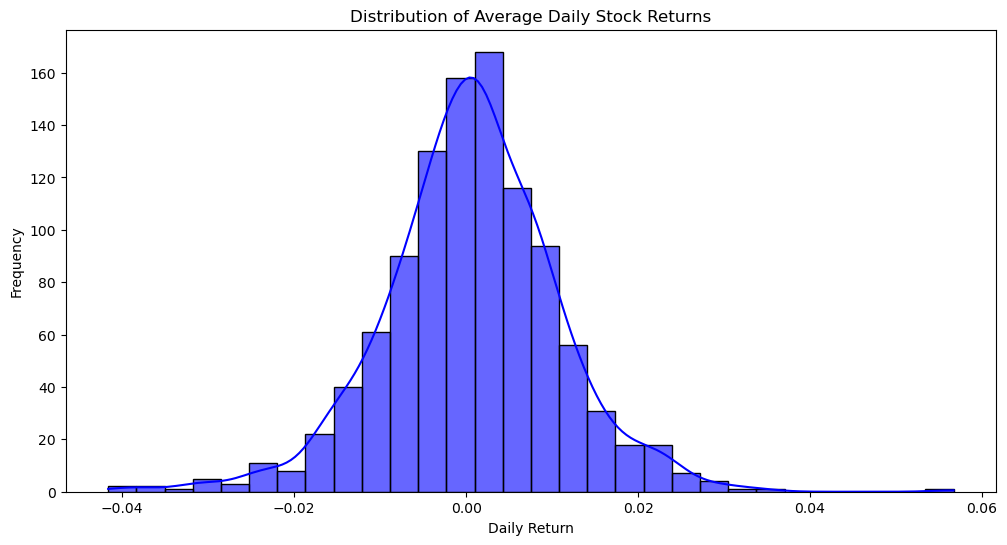

In [66]:
avg_returns = df.pct_change().mean(axis=1).dropna()

# Plotting histogram for average returns
plt.figure(figsize=(12, 6))
sns.histplot(avg_returns, bins=30, kde=True, color="blue", alpha=0.6)

# adding titles and labels
plt.title("Distribution of Average Daily Stock Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

## Top & Bottom 10 Stock Performers

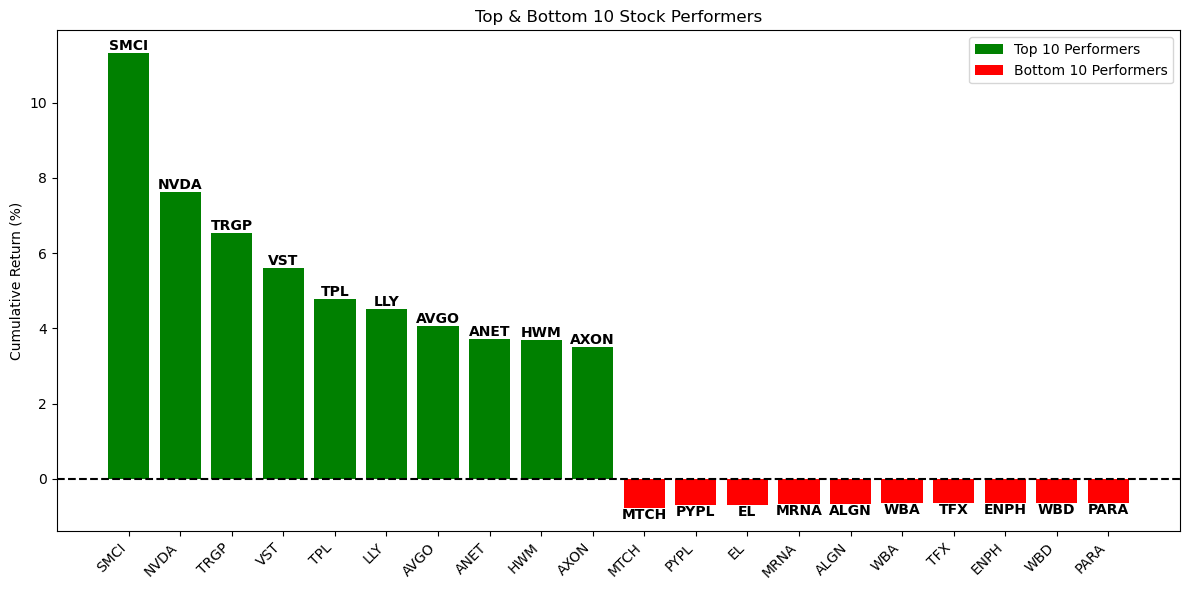

In [18]:
cumulative_returns = (df.iloc[-1] / df.iloc[0]) - 1

# now selecting top & bottom 10 performing stocks
top_10 = cumulative_returns.nlargest(10)
bottom_10 = cumulative_returns.nsmallest(10)

# creating the plot
plt.figure(figsize=(12, 6))
bars_top = plt.bar(top_10.index, top_10.values, color='green', label="Top 10 Performers")
bars_bottom = plt.bar(bottom_10.index, bottom_10.values, color='red', label="Bottom 10 Performers")

# adding stock tickers as text inside the bars
for bar, ticker in zip(bars_top, top_10.index):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), ticker, 
             ha='center', va='bottom', fontsize=10, color="black", fontweight="bold")

for bar, ticker in zip(bars_bottom, bottom_10.index):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), ticker, 
             ha='center', va='top', fontsize=10, color="black", fontweight="bold")

# final formatting
plt.axhline(0, color='black', linestyle='--')
plt.title("Top & Bottom 10 Stock Performers")
plt.ylabel("Cumulative Return (%)")
plt.xticks(rotation=45, ha="right")  # Rotate labels for readability
plt.legend()
plt.tight_layout()  # Ensure labels fit well
plt.show()

## Stocks Correlation Matrix

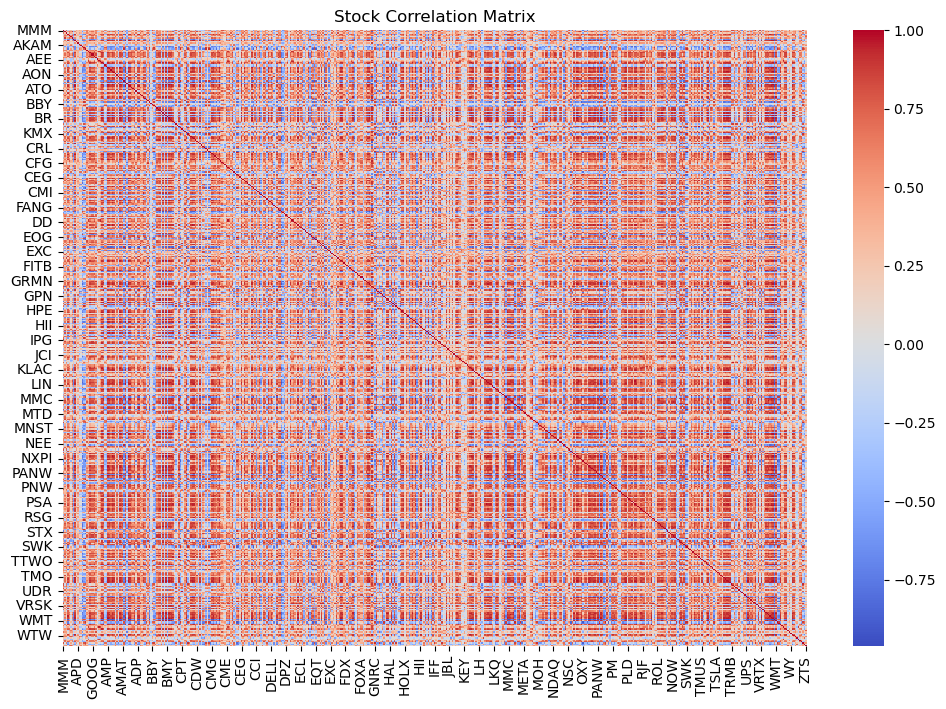

In [72]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Stock Correlation Matrix")
plt.show()

## Stocks by Performance

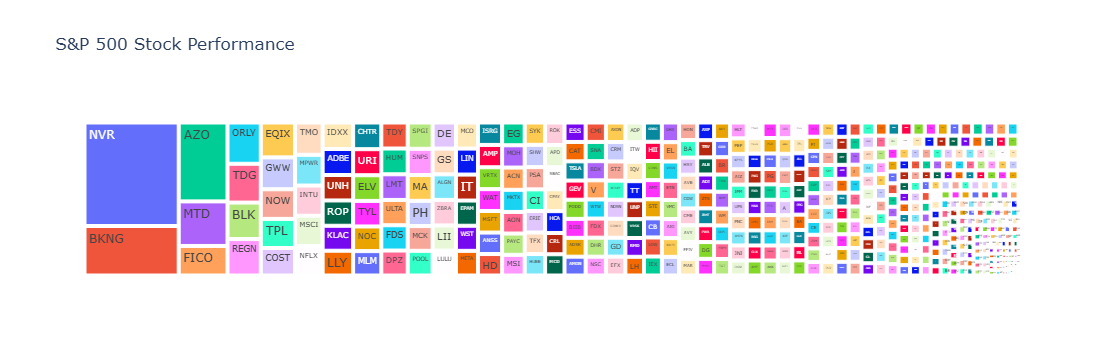

In [86]:
import plotly.express as px

sector_avg_returns = df.mean().reset_index()
sector_avg_returns.columns = ["Stock", "Average Return"]

fig = px.treemap(sector_avg_returns, path=["Stock"], values="Average Return", title="S&P 500 Stock Performance")
fig.show()

## Best Performing Sectors

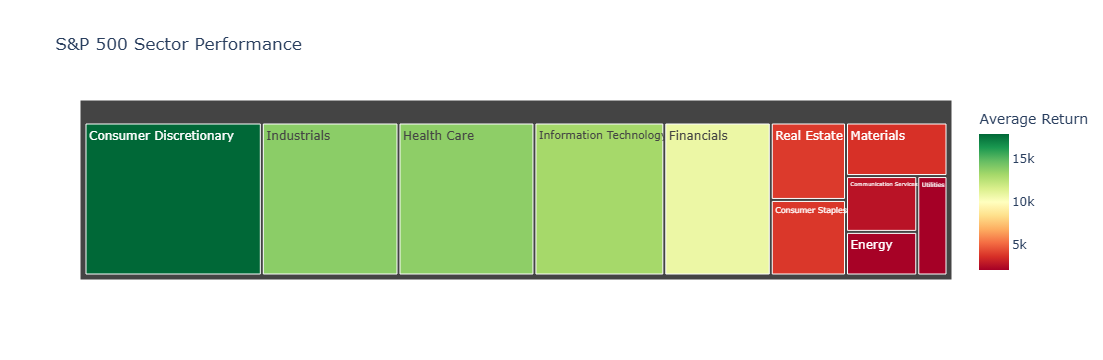

In [78]:
sector_df = pd.DataFrame(list(sector_info.items()), columns=["Stock", "Sector"])

# Compute average returns for each stock
average_returns = df.mean().reset_index()
average_returns.columns = ["Stock", "Average Return"]

# Merge sector information
sector_returns = pd.merge(average_returns, sector_df, on="Stock", how="left")

# Aggregate by sector
sector_summary = sector_returns.groupby("Sector", as_index=False).sum()

# Plot Treemap
fig = px.treemap(
    sector_summary, 
    path=["Sector"], 
    values="Average Return", 
    title="S&P 500 Sector Performance",
    color="Average Return", 
    color_continuous_scale="RdYlGn"  # Red for losses, Green for gains
)

fig.show()

# Optimisation Model

In [11]:
model = Model("SP500_Portfolio_Optimization")

stocks = expected_returns.index.tolist() 
w = model.addVars(stocks, lb=0, ub=1, vtype=GRB.CONTINUOUS, name="weights")

# Constranit 3: At least invest in  25 stocks in profolio (Using Binary)
y = model.addVars(stocks, vtype=GRB.BINARY, name="InvestOrNot")

# Constraint 6: Diversed by the industry
## Set up industry group
industry_groups = {}
for s in stocks:
    ind = sector_info[s]
    industry_groups.setdefault(ind, []).append(s)

##Set binary for every industry
z = model.addVars(list(industry_groups.keys()), vtype=GRB.BINARY, name="industrySelected")

Set parameter Username
Academic license - for non-commercial use only - expires 2026-01-08


## Optimisation Function

In [29]:
# Setup Optimization Function（Maximise Expected Return - Risk Aversion）
risk_aversion = 0.5  # Risk Capacity (changeable)
expected_portfolio_return = sum(expected_returns[s] * w[s] for s in stocks)
portfolio_risk = sum(w[i] * w[j] * cov_matrix.loc[i, j] for i in stocks for j in stocks)
model.setObjective(expected_portfolio_return - risk_aversion * portfolio_risk, GRB.MAXIMIZE)

## Constraints

In [23]:
# Constranit 1: Total Proportion = 100% -> no cash position
model.addConstr(sum(w[s] for s in stocks) == 1, "TotalInvestment")

# Constranit 2: Set the upper limit of 10% for individual stock
for s in stocks:
    model.addConstr(w[s] <= 0.10, f"MaxStock_{s}") 
    
for s in stocks:
    model.addConstr(w[s] <= y[s], f"LinkBinary_{s}")
model.addConstr(sum(y[s] for s in stocks) >= 25, "MinStockHoldings")

#  Constranit 3: Set the lower limit of 1% for invested stock
for s in stocks:
    model.addConstr(w[s] >= 0.01 * y[s], f"MinInvestment_{s}")

# Constranit 4: Set the upper limit of market risk of 10%
model.addConstr(sum(w[i] * w[j] * cov_matrix.loc[i, j] for i in stocks for j in stocks) <= 0.10, "MaxRisk")

## Connect stock binary with industry
for ind, group in industry_groups.items():
    for s in group:
        model.addConstr(y[s] <= z[ind], f"LinkIndustry_{s}_{ind}")
    model.addConstr(z[ind] <= sum(y[s] for s in group), f"IndustryActive_{ind}")

## Diversed industry in 10 different industries
model.addConstr(sum(z[ind] for ind in industry_groups.keys()) >= 10, "MinIndustryDiversification")

<gurobi.Constr *Awaiting Model Update*>

## Results

In [31]:
# Execution
model.optimize()

# Show the result
print("\n🔹 Optimal Portfolio Allocation:")
for s in stocks:
    print(f"{s}: {w[s].x:.4f}")
print("\n🔹 Optimal Portfolio Allocation with Sector:")
for s in stocks:
    if w[s].x > 1e-3:  # 選擇一個小的閾值，代表被選中
        print(f"{s}: {w[s].x:.4f}, Sector: {sector_info.get(s, 'Unknown')}")

Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i5-1035G1 CPU @ 1.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 4036 rows, 1013 columns and 10064 nonzeros
Model fingerprint: 0x234ecc27
Model has 125751 quadratic objective terms
Model has 2 quadratic constraints
Variable types: 501 continuous, 512 integer (512 binary)
Coefficient statistics:
  Matrix range     [1e-02, 1e+00]
  QMatrix range    [1e-07, 2e+00]
  Objective range  [5e-05, 2e+00]
  QObjective range [3e-06, 3e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e-01, 3e+01]
  QRHS range       [1e-01, 1e-01]

MIP start from previous solve produced solution with objective 0.694449 (0.31s)
Loaded MIP start from previous solve with objective 0.694449

Presolve removed 2519 rows and 0 columns
Presolve time: 0.67s
Presolved: 1517 rows, 1013 columns, 4531 nonzeros
P

In [33]:
# CALCULATE Total Return
portfolio_return = sum(w[s].x * expected_returns[s] for s in stocks)

# Calculate total risk
portfolio_risk = sum(w[i].x * w[j].x * cov_matrix.loc[i, j] for i in stocks for j in stocks)

print("\n📊 Portfolio Performance:")
print(f"✅ Expected Return: {portfolio_return:.6f}")
print(f"✅ Portfolio Risk (Variance): {portfolio_risk:.6f}")
print(f"✅ Portfolio Risk (Std Dev): {portfolio_risk ** 0.5:.6f}") 



📊 Portfolio Performance:
✅ Expected Return: 0.883283
✅ Portfolio Risk (Variance): 0.018353
✅ Portfolio Risk (Std Dev): 0.135474


# Results Visualisation

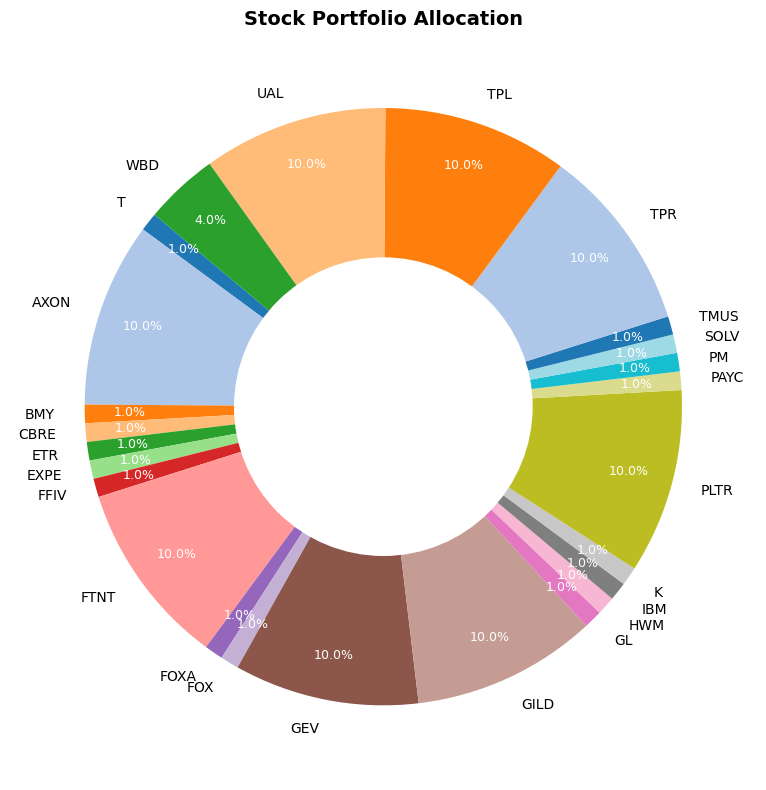

In [63]:
# Showing in graph
%matplotlib inline
colors = plt.cm.tab20.colors

weights = {s: w[s].x for s in stocks if w[s].x >= 0.01}  # Showing position which is larger than 1%

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    weights.values(), labels=weights.keys(), autopct='%1.1f%%', startangle=140, 
    colors=colors, pctdistance=0.85, textprops={'fontsize': 10}
)

for text in texts:
    text.set_fontsize(10)
    text.set_color('black')

for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_color('white')

# Draw center circle for a donut-style pie chart
centre_circle = plt.Circle((0,0),0.50,fc='white')
fig.gca().add_artist(centre_circle)

ax.set_title("Stock Portfolio Allocation", fontsize=14, fontweight='bold')

# Save and show the figure
plt.tight_layout()
plt.show()


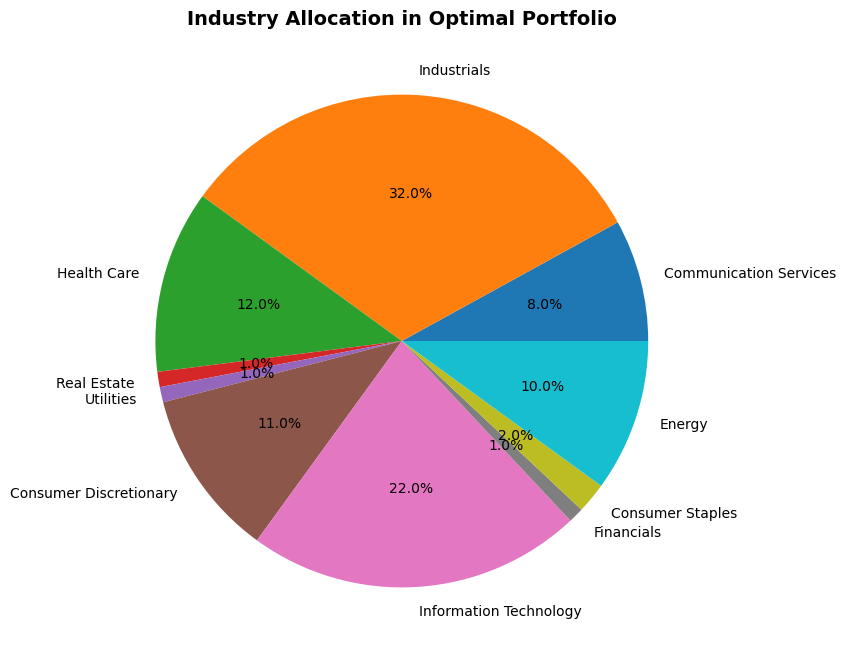

In [69]:
industry_weights = {}
for s, weight in weights.items():
    #"Unknown"
    ind = sector_info.get(s, "Unknown")
    industry_weights[ind] = industry_weights.get(ind, 0) + weight

plt.figure(figsize=(8, 8))
plt.pie(industry_weights.values(), labels=industry_weights.keys(), autopct='%1.1f%%')
plt.title("Industry Allocation in Optimal Portfolio", fontsize=14, fontweight='bold')
plt.show()